## 1. Exploratory Data Analysis (EDA) notebook
Data exploratie notebook klachten dataset

### 1.1 Packages importeren 

In [29]:
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from collections import Counter

In [30]:
# Pandas display opties aanpassen
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', 200)

### 1.2 Dataset inladen

In [31]:
df = pd.read_csv('klachten.csv')
y = df['Product'] # target 

In [32]:
df.index = df['ID'] 
df.drop(columns='ID', inplace=True)
# 'ID' kolom de index kolom maken

In [33]:
# Train-test split
train_df, test_df = train_test_split(df, test_size=0.3, random_state=42, stratify=y)

### 1.3 Basis analyse

In [34]:
# Aantal kolommen en rijen in de train dataset
df.shape
print("De dataset bevat {} rijen en {} kolommen.".format(df.shape[0], df.shape[1]))

De dataset bevat 14887 rijen en 4 kolommen.


In [35]:
# Eerste vijf rijen van de trainingsset bekijken
df.head().T

ID,2234392,2447005,2124501,1851449,2419713
Datum_ontvangst,2024-12-03,2025-04-21,2024-09-21,2024-03-27,2025-04-04
Product,Bankrekening,Bankrekening,Bankrekening,Bankrekening,Bankrekening
Omschrijving,"ON XX/XX/2016 I had a deposit of XXXX into my account and on the same day I had XXXX different companies authorize XXXX different transactions in the amount of XXXX and XXXX both of which were approved. Then on XX/XX/2016, while those XXXX transactions where still pending I used my debit card for XXXX other transactions XXXX for XXXX and another for gas in the amount of XXXX, at the close of business on XX/XX/XXXX those XXXX transactions where both still pending and my bank which is Bank of America preceeded to charge me an verdraft fee for both the first XXXX and the XXXX, stating that at the time those items posted that my account was overdrawn, at which time it was not, I had the funds to cover the items.When I called and spoke to Bank of America, they stated that at the time those items came into my account it was overdrawn, which in fact it was NOT. The representative proceeded to show me on another screen where it showed it was overdrawn. I noticed that on that screen Bank of America re-layered the transaction showing the XXXX pending transactions as still pending but coming in first and the rest of the transactions after and that is how they are getting away with charging me the fees. How can a bank charge overdraft fees on transactions that were already approved and had not overdrafted my account. So the XXXX transactions that they charged me fees on where autherized first on XXXX/XXXX/2016 and posted on XXXX/XXXX/2016, but they are saying at the time they posted to my account it was negative, however the item that they said made it negative was a transactions that was done on XXXX/XXXX/2016 and is still pending and will not post to my account until the close of business on XXXX/XXXX/2016.","Chase Bank accepted a {$3500.00} check for deposit which was made payable jointly to myself, my wife, and XXXX XXXX XXXX , XXXX ( "" XXXX '' ) as non-alternative payees, with an unambiguous "" & '' symbol on the payee line. XXXX forged endorsements for myself and my wife and deposited the check without authorization from myself or my wife, in violation of California law including Californ ia Commercial Code Section 3110 ( d ). Our insurance company wrote a letter to XXXX XXXX XXXX ( t he payor bank ) stating that I was entitled to {$1400.00} of the check amount. XXXX XXXX XXXX made a claim with Chase Ban k ( th e deposit bank ). On XXXX XXXX , XXXX , Chase Bank improperly denied the claim on the basis of a purported and unlawful power of attorney. Chase Bank 's denial of the claim was an unlawful, unfair, or fraudulent business practice within the meaning of California Business & Professions Code Section 17200, because in so doing, Chase Bank assisted XXXX in stealing my {$1400.00}. Under Californi a Probate Code Section 4121, a p ower of attorney is legally sufficient only if it is acknowledged before a notary public or signed by at lea st 2 witne sses. The purported power of attorney which Chase Bank honored was not so notarized or witnessed. As such, under Califo rnia Commercial Code Section 3403, the endorsements were ineffective. Chase Bank violated Califor nia Commercial Code Section 3404 ( d ) by failing to exercise ordinary care in paying or taking the check with the forged endorsements and refusing to honor the claim. We have been trying to persuade XXXX to return the money for years, but XXXX refuses. XXXX has admitted that it signed our names despite promising to hold the check while we were resolving billing issues with XXXX . There is no dispute of fact that XXXX signed our names.",I tried to open an account with Bank of America and without giving a reason the bank refused to open an account.,"On XXXX my account was gotten into on USAA by phone number XXXX at XXXX. At XXXX and at XXXX XXXX attempted to get into the phone 

In [36]:
# stats categorische variabelen 
stats_cat = df.describe(include='object').T.reset_index()
stats_cat

,index,count,unique,top,freq
0,Datum_ontvangst,14887,771,2024-09-21,43
1,Product,14887,6,Incasso,4094
2,Omschrijving,14887,14816,"I am filing this complaint because Experian has ignored my request to provide me with the documents that their company has on file that was used to verify the accounts I disputed. Being that they have gone past the 30 day mark and can not verify these accounts, under Section 611 ( 5 ) ( A ) of the FCRA - they are required to "" ... promptly delete all information which can not be verified '' that I have disputed. Please resolve this manner as soon as possible. Thank you.",10
3,Antwoord_bedrijf,14887,5,Closed with explanation,11610


In [37]:
print("Aantal categorische kolommen:", df.select_dtypes(include='object').shape[1])
print("Aantal numerieke kolommen:", df.select_dtypes(include=['int64', 'float64']).shape[1])

Aantal categorische kolommen: 4
Aantal numerieke kolommen: 0


In [38]:
# Datatypes en null-waarden in de trainingsset bekijken
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 14887 entries, 2234392 to 2286310
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Datum_ontvangst   14887 non-null  object
 1   Product           14887 non-null  object
 2   Omschrijving      14887 non-null  object
 3   Antwoord_bedrijf  14887 non-null  object
dtypes: object(4)
memory usage: 581.5+ KB


#### Conclusie basis analyse
- Op 21 september 2024 zijn de meeste klachten ingediend: 43 klachten 
<br>

- De productsector 'Incasso' heeft de meeste klachten: 4049
<br>
- Er zijn dubbele waarden in de kolom 'Omschrijving': er hoort eigenlijk geen omschrijving-tekst te zijn die vaker van 1 keer voorkomt. 
<br>
Er zitten geen nullwaardes in de dataset. Alle variabelen behalve `ID` zijn van het object type (tekst)

### 1.4 Analyse: Product (target)

In [39]:
# Verdeling van de Product-sectoren in de trainingsset
df['Product'].value_counts()

Product
Incasso               4094
Hypotheek             3314
Kredietregistratie    3159
Creditcard            1884
Bankrekening          1489
Consumentenkrediet     947
Name: count, dtype: int64

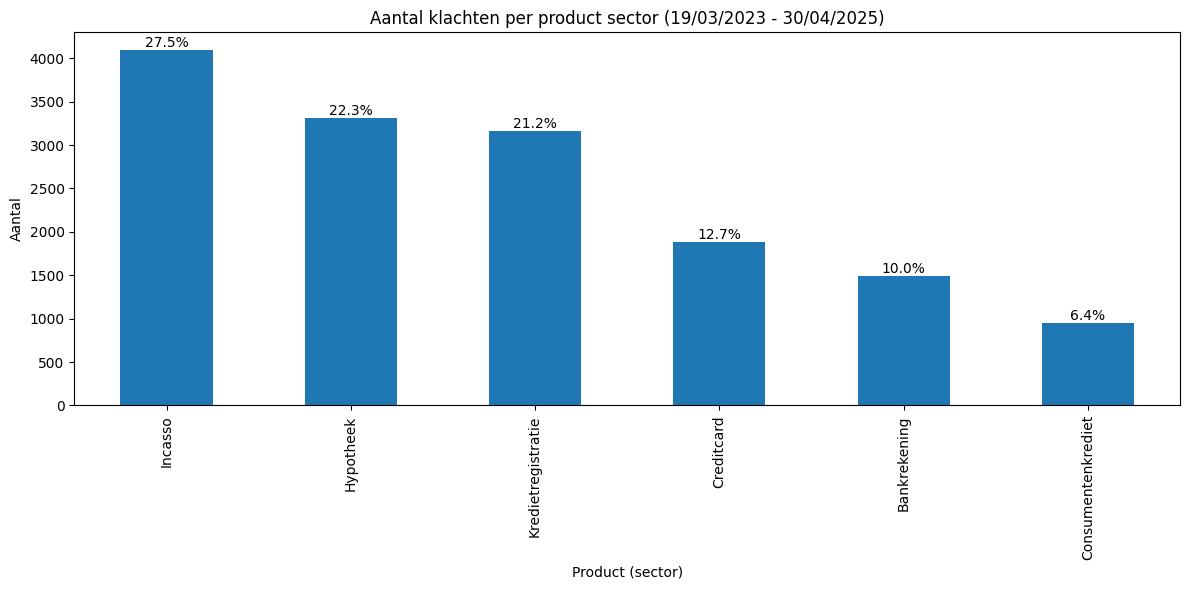

In [ ]:
counts_product = df['Product'].value_counts() # Aantal klachten per product sector
percentages = counts_product / counts_product.sum() * 100 # Percentage klachten per product sector

# Plotten van de verdeling van klachten per product sector
ax = counts_product.plot(kind='bar', figsize=(12,6))
ax.set_xlabel("Product (sector)")
ax.set_ylabel("Aantal")
ax.set_title("Aantal klachten per product sector (19/03/2023 - 30/04/2025)")

# Percentages boven de bars weergeven 
for i, v in enumerate(counts_product):
    ax.text(i, v, f"{percentages.iloc[i]:.1f}%", ha="center", va="bottom") 

plt.tight_layout()
plt.show()

In [41]:
# Relatieve verdeling productsectoren (class imbalance)
(counts_product / counts_product.sum()).round(3)

Product
Incasso               0.275
Hypotheek             0.223
Kredietregistratie    0.212
Creditcard            0.127
Bankrekening          0.100
Consumentenkrediet    0.064
Name: count, dtype: float64

#### Conclusie Product analyse:
- De sector met de meeste klachten is 'Incasso' met 27.5% van alle klachten. 

- De klachten per sector zijn ongebalanceerd. Dit kan invloed hebben op modelprestaties

### 1.5 Analyse: Omschrijving

In [42]:
# Statistische informatie over de lengte van de klachtenbeschrijvingen
exploratie_df = df.copy()
exploratie_df['len'] = exploratie_df['Omschrijving'].str.len()
exploratie_df['len'].describe().round(2)

count    14887.00
mean      1021.46
std        910.19
min         12.00
25%        378.00
50%        714.00
75%       1366.00
max      10761.00
Name: len, dtype: float64

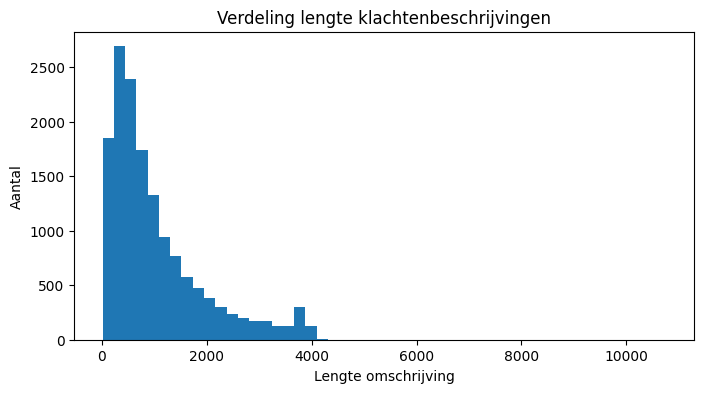

In [57]:
plt.figure(figsize=(8,4))
plt.hist(exploratie_df['len'], bins=50)
plt.xlabel("Lengte omschrijving")
plt.ylabel("Aantal")
plt.title("Verdeling lengte klachtenbeschrijvingen")
plt.show()

In [44]:
exploratie_df[exploratie_df['len'] < 20][['Omschrijving', 'Product']].head()

,Omschrijving,Product
ID,,
1336598,Identity theft,Creditcard
2338528,"Threats, harassment",Creditcard
2251144,Debt is n't mine.,Incasso
2062135,I paid XXXX.,Incasso
1978567,I paid this bill.,Incasso


In [45]:
# Gemiddelde lengte van klachtenbeschrijvingen per product sector
exploratie_df.groupby('Product')['len'].mean().round(2)

Product
Bankrekening          1211.25
Consumentenkrediet    1074.25
Creditcard            1120.45
Hypotheek             1431.55
Incasso                777.96
Kredietregistratie     742.50
Name: len, dtype: float64

In [ ]:
# Aantal duplicaten in omschrijving tellen
df['Omschrijving'].duplicated().sum()

np.int64(39)

In [ ]:
# Rijen met duplicaten selecteren trainset
explore_duplicates = train_df.loc[
    train_df['Omschrijving'].duplicated(keep=False)
].copy()

# Sorteren zodat de duplicates bij elkaar staan 
explore_duplicates = explore_duplicates.sort_values('Omschrijving')

explore_duplicates

,Datum_ontvangst,Product,Omschrijving,Antwoord_bedrijf
ID,,,,
2152667,2024-10-08,Kredietregistratie,Experian is not responding to my requests to investigate and remove accounts that do not belong to me from my credit report.,Closed with explanation
2096759,2024-09-07,Kredietregistratie,Experian is not responding to my requests to investigate and remove accounts that do not belong to me from my credit report.,Closed with explanation
2362106,2025-02-27,Kredietregistratie,I am a victim of identity theft. There is Fraudulent Information on Credit Reports which were made without my knowledge or permission. \nBut Credit Bureaus have failed to give me investigation result,Closed with explanation
2361993,2025-02-27,Kredietregistratie,I am a victim of identity theft. There is Fraudulent Information on Credit Reports which were made without my knowledge or permission. \nBut Credit Bureaus have failed to give me investigation result,Closed with explanation
2041468,2024-08-02,Kredietregistratie,"I am filing this complaint because Equifax has ignored my request to provide me with the documents that their company has on file that was used to verify the accounts I disputed. Being that they have gone past the 30 day mark and can not verify these accounts, under Section 611 ( 5 ) ( A ) of the FCRA - they are required to "" ... promptly delete all information which can not be verified '' that I have disputed. Please resolve this manner as soon as possible. Thank you.",Closed with explanation
...,...,...,...,...
1403881,2023-06-03,Incasso,"This debt is not known to me. I recently requested my Free Credit reports to access my credit history before I applied for my XXXX mortgage which I have been diligently addressing my credit so that i would be in a good position when ready so I request full validation from the crediting company. This request is for more than just a simple statement without detail. Rather, I must requisition a careful documentation, including statements, contracts, copies of checks, and any other pertinent information.",Closed with explanation
1510127,2023-08-09,Kredietregistratie,"While checking my personal credit report, I noticed an unauthorized and fraudulent credit inquiry made by XXXX on or about XX/XX/XXXX on Experian. I did not authorized anyone employed by this company to make any inquiry and view my credit report. XXXX has violated the Fair Credit Reporting Act Section 1681b ( c ). They were not legally entitled to make this fraudulent inquiry. This is a serious breach of my privacy rights. \nI have requested that they mail me a copy of my signed authorization form that gave them the right to view my credit within five ( 5 ) business days so that I can verify its validity and advised them that if they can not provide me with proof that I authorized them to view my credit report then I am demanding that they contact the credit bureaus immediately and have them remove the unauthorized and fraudulent hard inquiry immediately. I also requested that they remove my personal information from their records. My Social Security # is XXXX and my Date of Birth is XX/XX/XXXX in case it is needed to locate the fraudulent inquiry in their system.",Closed with non-monetary relief
1509808,2023-08-08,Kredietregistratie,"While checking my personal credit report, I noticed an unauthorized and fraudulent credit inquiry made by XXXX on or about XX/XX/XXXX on Experian. I did not authorized anyone employed by this company to make any inquiry and view my credit report. XXXX has violated the Fair Credit Reporting Act Section 1681b ( c ). They were not legally entitled to make this fraudulent inquiry. This is a serious breach of my privacy rights. \nI have requested that they mail me a copy of my signed authorization form that gave them the right to view my credit within five ( 5 ) business days so that I can verify its validity and advised them that if they can not provide me with proof that I authorized them to view my credit report then I am 

In [48]:
# Rijen met duplicaten selecteren hele dataset (niet alleen train)
explore_duplicates = df.loc[
    df['Omschrijving'].duplicated(keep=False)
].copy()

explore_duplicates = explore_duplicates.sort_values('Omschrijving')

explore_duplicates

,Datum_ontvangst,Product,Omschrijving,Antwoord_bedrijf
ID,,,,
1948868,2024-06-01,Incasso,"3rd party collection agency FCBS calling multiple times and hanging up, then refusing to tell me why they are calling. Finally they disclose an attempt to collect a debt which was paid in XXXX 2015. I have advised them to cease and desist.",Closed with explanation
1949370,2024-06-01,Incasso,"3rd party collection agency FCBS calling multiple times and hanging up, then refusing to tell me why they are calling. Finally they disclose an attempt to collect a debt which was paid in XXXX 2015. I have advised them to cease and desist.",Closed with explanation
1551911,2023-09-03,Kredietregistratie,Classification of multiple names is ridiculous. I was married. I have since divorced and no longer use his name. He is also deceased as of last year.,Closed with non-monetary relief
1541379,2023-08-27,Kredietregistratie,Classification of multiple names is ridiculous. I was married. I have since divorced and no longer use his name. He is also deceased as of last year.,Closed with explanation
2398806,2025-03-22,Incasso,Company threatend to go to court house and send a bench wareant out for my arrest the company threatend to put my relatives and named by there names on the court order as witnesses,Closed with explanation
...,...,...,...,...
1610153,2023-10-16,Kredietregistratie,"While checking my personal credit report, I discovered an Unauthorized and Fraudulent credit inquiry made without my KNOWLEDGE or CONSENT by XXXX XXXX XXXX on or about XXXX/XXXX/2015 on EXPERIAN credit file. I did not authorized or give permission to anyone employed by this company to make any inquiry and view my credit report. XXXX XXXX XXXX has violated the Fair Credit Reporting Act Section 1681b ( c ). They were not legally entitled to make this fraudulent inquiry. This is a serious breach of my privacy rights. I am requesting that they mail me a copy of my signed authorization form that gave them the right to view my credit within five ( 5 ) business days so that I can verify its validity and advised them that if they can not provide me with proof that I authorized them to view my credit report then I am demanding that they contact the credit bureaus and have them remove the unauthorized and fraudulent hard inquiry immediately.",Closed with non-monetary relief
1509808,2023-08-08,Kredietregistratie,"While checking my personal credit report, I noticed an unauthorized and fraudulent credit inquiry made by XXXX on or about XX/XX/XXXX on Experian. I did not authorized anyone employed by this company to make any inquiry and view my credit report. XXXX has violated the Fair Credit Reporting Act Section 1681b ( c ). They were not legally entitled to make this fraudulent inquiry. This is a serious breach of my privacy rights. \nI have requested that they mail me a copy of my signed authorization form that gave them the right to view my credit within five ( 5 ) business days so that I can verify its validity and advised them that if they can not provide me with proof that I authorized them to view my credit report then I am demanding that they contact the credit bureaus immediately and have them remove the unauthorized and fraudulent hard inquiry immediately. I also requested that they remove my personal information from their records. My Social Security # is XXXX and my Date of Birth is XX/XX/XXXX in case it is needed to locate the fraudulent inquiry in their system.",Closed with non-monetary relief
1510127,2023-08-09,Kredietregistratie,"While checking my personal credit report, I noticed an unauthorized and fraudulent credit inquiry made by XXXX on or about XX/XX/XXXX on Experian. I did not authorized anyone employed by this company to make any inquiry and view my credit report. XXXX has violated the Fair Credit Reporting Act Section 1681b ( c ). They were not legally entitled to make this fraudulent inquiry. This is a serious breach of my privacy rights. \nI have requested that they ma

#### Conclusie Omschrijving Analyse:
- Er zijn in totaal 122 dubbele omschrijving rijen in de dataset.
- Twee rijen hebben exact dezelfde omschrijving (zie afbeelding), maar zijn gecategoriseerd met verschillende productsectoren. Dat kan wijzen op verkeerd gelabelde data. TODO: Onderzoeken/navragen bij opdrachtgever

- Er zijn in totaal 122 dubbele omschrijving rijen in de hele dataset 

### 1.6 Analyse: Antwoord bedrijf

In [ ]:
df['Antwoord_bedrijf'].value_counts()

Antwoord_bedrijf
Closed with explanation            8155
Closed with non-monetary relief    1207
Closed with monetary relief         735
Closed                              251
Untimely response                    72
Name: count, dtype: int64

#### Conclusie 'Antwoord bedrijf' Analyse:
- De data is sterk scheef verdeeld en bevat weinig variatie. Daarnaast beschrijft deze variabele de afhandeling van de klacht en niet de inhoud ervan. Daarom wordt Antwoord_bedrijf niet meegenomen als feature voor het model.

### 1.7 Analyse: Datum ontvangst 

In [53]:
# datum string omzetten naar datetime
df['Datum_ontvangst'] = pd.to_datetime(df['Datum_ontvangst'])

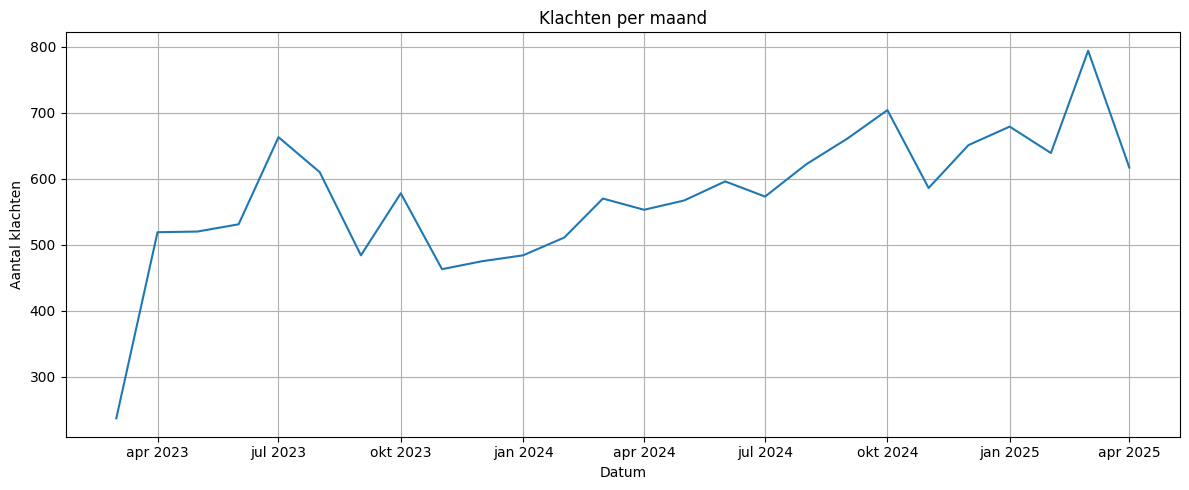

In [ ]:
counts = df.groupby(df['Datum_ontvangst'].dt.to_period('M')).size() # groeperen op jaar-maand en aantallen per maand tellen 
counts.index = counts.index.to_timestamp() # Omzetten naar timestamp voor plotting

fig, ax = plt.subplots(figsize=(12,5))
ax.plot(counts.index, counts.values)

# maand - jaar labels 
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

plt.title("Klachten per maand")
plt.xlabel("Datum")
plt.ylabel("Aantal klachten")
plt.grid(True)
plt.tight_layout()
plt.show()

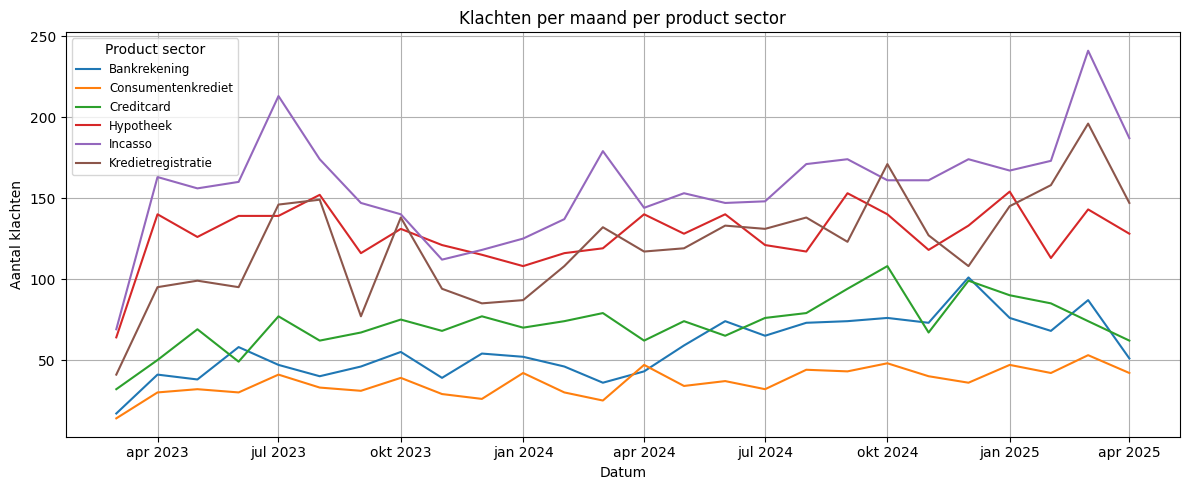

In [55]:
# groeperen per maand en per product sector
counts_sector = (
    df.groupby([df['Datum_ontvangst'].dt.to_period('M'), 'Product']).size().unstack(fill_value=0))

# index terugzetten naar timestamp 
counts_sector.index = counts_sector.index.to_timestamp()

fig, ax = plt.subplots(figsize=(12,5))

for sector in counts_sector.columns:
    ax.plot(counts_sector.index, counts_sector[sector], label=sector)

# Labels en titel
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y')) # maand - jaar labels 
plt.title("Klachten per maand per product sector")
plt.xlabel("Datum")
plt.ylabel("Aantal klachten")
plt.legend(title="Product sector", loc='upper left', fontsize=8.5)
plt.grid(True)
plt.tight_layout()
plt.show()

#### Conclusie Analyse: Datum ontvangst
Klachten per maand: 
- Het aantal klachten per maand schommelt, maar de grafiek laat wel een stijging in de loop van de tijd zien. 
- Er zijn vier momenten waarop het aantal klachten omhoog schiet: in juli 2023, oktober 2023, oktober 2024 en rond maart 2025.  

Klachten per maand per product sector:
- Incasso is duidelijk de grootste bron van klachten. Daarna volgen hypotheek en kredietregistratie. De andere productgroepen hebben het laagste aantal maandelijkse klachten. 

- Kredietregistratie en incasso laten een vergelijkbaar patroon zien: hun pieken en dalen liggen vaak dicht bij elkaar. Mogelijk hebben de klachten dezelfde of een soortgelijke oorzaak. 

## Eindconclusie EDA 
- De variabele Omschrijving wordt gebruikt als input en Product als targetvariabele voor het trainen van de modellen. De variabele ID wordt gebruikt als index, zodat voorspellingen herleidbaar zijn naar individuele klachten.
- Op basis van de EDA wordt verwacht dat de overige variabelen geen significante aanvullende voorspellende waarde leveren voor productclassificatie.